# ***CAPSTONE PROJECT FOR TIRA BEAUTY - BTAA***

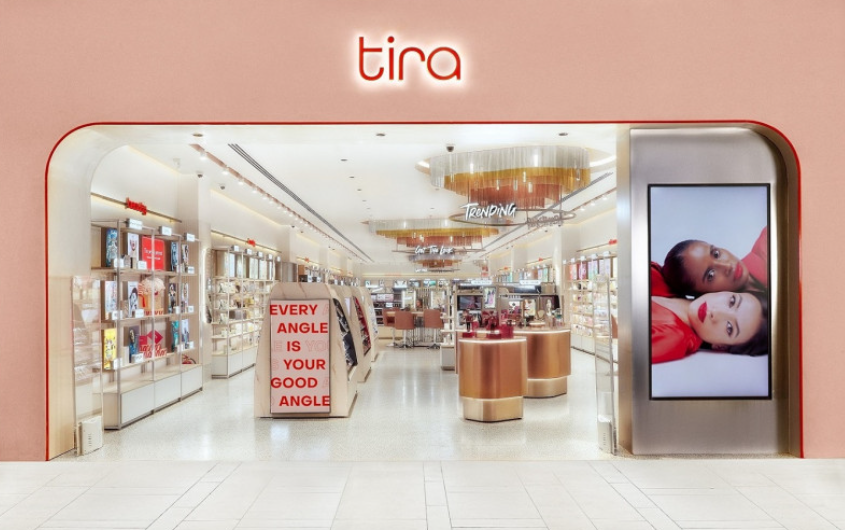

# **ChatBot - Tira Beauty**

In [ ]:
import random
from IPython.display import display
import ipywidgets as widgets

#Knowledge Base for Tira Beauty
intents = {
    #Priority 1: High-Specificity/Command Intents
    "goodbye": {
        "patterns": ["bye", "goodbye", "see you later", "thanks for the help", "exit", "thank you", "that's all"],
        "responses": ["Goodbye! Thank you for visiting Tira Beauty. Hope to see you again soon!", "Thanks for chatting. Have a great day and happy shopping!", "See you soon! Feel free to reach out if you have any more beauty questions."],
    },
    "order_status": {
        "patterns": ["where is my order", "track my package", "order status", "shipping details", "when will my delivery arrive", "my order"],
        "responses": ["To check your order status, please provide your **Order Number**. You can find the tracking link in your order confirmation email.", "I can't access live order data, but please check the tracking number sent to your email or log in to your Tira account for the latest update."],
    },
    "return_policy": {
        "patterns": ["return policy", "exchange a product", "how to return", "damaged item", "refund process", "cancellation"],
        "responses": ["Our return policy allows returns within **7 days** of delivery, provided the product is unused and in its original packaging. Please check the 'Returns' section for full details.", "The return process is simple! Go to 'My Orders' and select the item you wish to return, but note that products like opened perfume may not be eligible."],
    },
    "promotions": {
        "patterns": ["current offers", "sales", "discounts", "coupon code", "new promotions", "loyalty program", "tira treats"],
        "responses": ["We have exciting offers running! Check the **Tira Home Page banner** for the latest discounts and special bundles. Also, look out for our 'Tira Treats' loyalty points!", "Yes, we often have sales! Sign up for our newsletter to get direct notifications about coupon codes and upcoming brand discounts."],
    },
    #Priority 2: Product/Category Specific Intents
    "skincare_query": {
        "patterns": ["moisturizer", "sunscreen", "serums for acne", "night cream", "anti-aging", "oily skin routine", "dry skin", "combination skin", "best toner", "face wash"],
        "responses": ["For skincare, we have top brands for every concern! Could you specify if you are looking for products for oily, dry, or combination skin?", "Check out our 'Skincare' section! We have a wide range of moisturizers, sunscreens, and specialized serums. Brands like Laneige and Innisfree are popular."],
    },
    "makeup_query": {
        "patterns": ["foundation shades", "lipstick", "mascara", "eyeshadow palette", "eyeliner", "waterproof makeup", "bridal makeup", "primer", "concealer", "blush", "highlighter"],
        "responses": ["We have an extensive makeup collection! For foundation, you can use our **Virtual Try-On** feature to find your perfect shade. Popular brands include MAC and Maybelline.", "Looking for something specific? We carry lipsticks, foundations, eye makeup, and more. Our 'Best Sellers' section is great for popular items."],
    },
    #Priority 3: General/Broad Intents
    "greeting": {
        "patterns": ["hi", "hello", "hey", "good morning", "greetings", "hi there", "namaste"],
        "responses": ["Hello! Welcome to Tira Beauty. How can I assist you today?", "Hi there! I can help with product information, orders, and promotions.", "Welcome! Ask me about makeup, skincare, fragrances, or your order status."],
    },
    "product_categories": {
        "patterns": ["what categories do you have", "list of products", "available sections", "makeup category", "skincare category", "fragrance category", "haircare category", "bath and body", "what do you sell"],
        "responses": ["Tira Beauty offers a wide range of products across **Makeup**, **Skincare**, **Fragrances**, **Haircare**, and **Bath & Body**. You can explore them all on our website!", "We sell products in major categories like Skincare, Makeup, and Fragrance, featuring both Indian and international brands."],
    },
    "default": {
        "patterns": [],
        "responses": ["I'm sorry, I don't have information on that. I can help with product details, orders, or policies. Please try rephrasing your question.", "Could you ask about makeup, skincare, fragrances, orders, or returns?", "Apologies, I didn't understand. Try asking about a specific category or your order status."],
    }
}

def get_response(user_input):
    """
    Matches user input to an intent using keyword/phrase matching.
    The logic prioritizes checking intents in the order they appear in the dictionary.
    """
    user_input = user_input.lower().strip()
    found_intent = "default"

    for intent_tag, intent_data in intents.items():
        if intent_tag == "default":
            continue

        for pattern in intent_data["patterns"]:
            if pattern in user_input:
                found_intent = intent_tag
                return random.choice(intents[found_intent]["responses"])

    return random.choice(intents["default"]["responses"])


chat_history = widgets.Output()

text_input = widgets.Text(
    value='',
    placeholder='Type your question about products, orders, or policies...',
    description='You:',
    disabled=False
)

def on_submit(sender):
    """Function called when the user hits Enter."""
    user_message = text_input.value

    if not user_message.strip():
        return

    text_input.value = ''

    with chat_history:
        print(f"You: {user_message}")

    bot_response = get_response(user_message)
    with chat_history:
        print(f"🤖 Tira Bot: {bot_response}")

    if any(p in user_message.lower() for p in intents["goodbye"]["patterns"]):
        text_input.disabled = True
        with chat_history:
            print("--- Chat Ended. Happy Shopping! ---")

text_input.on_submit(on_submit)

with chat_history:
    print("🤖 Tira Bot: Hello! I can answer questions about Tira's products, orders, and general policies (e.g., 'best lipstick', 'where is my order'). Type 'bye' or 'exit' to end the chat.")

# Display the elements to start the interaction
display(chat_history, text_input)

Output()

Text(value='', description='You:', placeholder='Type your question about products, orders, or policies...')

# **Feature Importance - Tira Beauty**

In [ ]:
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def generate_customer_data(n=200):
    """Generates synthetic Tira Beauty customer data with stronger churn correlation."""
    data = {
        'Age': [random.randint(18, 65) for _ in range(n)],
        'Gender': [random.choice(['F', 'M', 'O']) for _ in range(n)],
        'Days_as_Customer': [random.randint(30, 1500) for _ in range(n)],
        'Total_Lifetime_Spend': [random.randint(5000, 200000) for _ in range(n)],
        'Avg_Visits_per_Month': [random.uniform(1.0, 15.0) for _ in range(n)],
        # Loyalty Tier: 0=None, 1=Bronze, 2=Silver, 3=Gold
        'Loyalty_Tier': [random.randint(0, 3) for _ in range(n)],
        'Days_Since_Last_Purchase': [random.randint(1, 180) for _ in range(n)],
        'Avg_Order_Value': [random.randint(800, 6000) for _ in range(n)],
        # Ratio of Skincare purchases to total orders (0.0 to 1.0)
        'Skincare_Purchases_Ratio': [random.uniform(0.0, 1.0) for _ in range(n)],
        'Churn': [0] * n
    }

    for i in range(n):
        # High Churn Probability
        if (data['Days_Since_Last_Purchase'][i] > 90 and
            data['Avg_Visits_per_Month'][i] < 3 and
            data['Loyalty_Tier'][i] < 2):
            if random.random() < 0.8:
                data['Churn'][i] = 1

        # Low Churn Probability
        elif (data['Days_Since_Last_Purchase'][i] < 30 and
              data['Avg_Order_Value'][i] > 4000 and
              data['Loyalty_Tier'][i] == 3):
            if random.random() < 0.1:
                data['Churn'][i] = 0
            else:
                data['Churn'][i] = 0

        # Moderate Churn Probability
        elif random.random() < 0.3:
             data['Churn'][i] = 1

    return data

#Creating Sample Data
data = generate_customer_data(n=200)
df = pd.DataFrame(data)

#Data Preparation
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0, 'O': 2})
X = df.drop('Churn', axis=1)
y = df['Churn']

#Train-Test Split (test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Model Building (Random Forest Classifier)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Prediction
y_pred = model.predict(X_test)

#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

#Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nFeature Importance:\n", importances.sort_values(ascending=False))

Accuracy: 0.65

Confusion Matrix:
 [[35  4]
 [17  4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.90      0.77        39
           1       0.50      0.19      0.28        21

    accuracy                           0.65        60
   macro avg       0.59      0.54      0.52        60
weighted avg       0.61      0.65      0.60        60


Feature Importance:
 Days_as_Customer            0.241233
Total_Lifetime_Spend        0.159106
Skincare_Purchases_Ratio    0.148941
Avg_Visits_per_Month        0.105836
Days_Since_Last_Purchase    0.096795
Age                         0.094954
Avg_Order_Value             0.089244
Loyalty_Tier                0.033938
Gender                      0.029954
dtype: float64


# **Recommender System - Tira Beauty**

In [ ]:
import pandas as pd
import random

#Generating Synthetic Data
def generate_tira_data(num_transactions=200):
    products = {
        'Skincare': ['Hydrating Serum', 'Face Wash', 'Sunscreen SPF50', 'Toner', 'Eye Cream', 'Retinol Night Cream'],
        'Makeup': ['Kajal', 'Lipstick', 'Foundation', 'Mascara', 'Lip Gloss', 'Setting Spray', 'Blush Palette'],
        'Fragrance': ['Perfume EDP', 'Deodorant Spray', 'EDT Gift Set'],
        'Haircare': ['Shampoo', 'Conditioner', 'Hair Oil', 'Leave-In Serum'],
        'Bath & Body': ['Body Lotion', 'Shower Gel', 'Aromatherapy Scrub']
    }

    categories = list(products.keys())
    customer_ids = [f'T{i:03}' for i in range(1, 51)]

    data = []

    for i in range(num_transactions):
        customer_id = random.choice(customer_ids)
        category = random.choice(categories)
        product_name = random.choice(products[category])

        if category == 'Skincare': amount = random.randint(700, 3500)
        elif category == 'Makeup': amount = random.randint(400, 3000)
        elif category == 'Fragrance': amount = random.randint(1500, 6000)
        elif category == 'Haircare': amount = random.randint(500, 1500)
        else: amount = random.randint(300, 1000)

        data.append({
            'CustomerID': customer_id,
            'ProductName': product_name,
            'Category': category,
            'AmountSpent': amount
        })

    return pd.DataFrame(data)

#Creating Sample Data
data = generate_tira_data(num_transactions=200)

#Display Basic Info
print("Sample Tira Beauty Data (First 10 of 200 Transactions):")
print(data.head(10))

#Group Customers - Purchase Trends
category_trends = data.groupby('Category')['AmountSpent'].sum().reset_index()
print("\nTotal Spending by Tira Category (200 Transactions):")
print(category_trends.sort_values(by='AmountSpent', ascending=False))

#Pre-Processing History For Realistic Filtering
customer_history = data.groupby('CustomerID')['ProductName'].apply(set).to_dict()

def recommend_product_filtered(row):
    """Recommends a complementary product, ensuring the customer hasn't bought it."""
    customer_id = row['CustomerID']
    category = row['Category']

    recommendation_map = {
        'Skincare': ['Advanced Retinol Night Cream', 'Face Oil Elixir', 'Peptide Serum'],
        'Makeup': ['Luxury Brush Set', 'High-Shine Liquid Highlighter', 'Professional Contour Kit'],
        'Fragrance': ['Designer EDP Travel Spray', 'Scented Candle Set'],
        'Haircare': ['Deep Conditioning Mask', 'Heat Protectant Spray', 'Scalp Massager'],
        'Bath & Body': ['Aromatherapy Body Scrub', 'Essential Oils Diffuser']
    }

    potential_recs = recommendation_map.get(category, ['Tira Gift Card'])

    purchased_products = customer_history.get(customer_id, set())
    available_recs = [rec for rec in potential_recs if rec not in purchased_products]

    if available_recs:
        return random.choice(available_recs)
    else:
        return 'Tira Gift Card'


data['Recommendation'] = data.apply(recommend_product_filtered, axis=1)

print("\nCustomer Recommendations (Next Suggested Purchase with History Filter):")
print(data[['CustomerID', 'Category', 'ProductName', 'Recommendation']].drop_duplicates(subset=['CustomerID']))

Sample Tira Beauty Data (First 10 of 200 Transactions):
  CustomerID         ProductName     Category  AmountSpent
0       T038             Shampoo     Haircare          941
1       T009  Aromatherapy Scrub  Bath & Body          654
2       T005       Blush Palette       Makeup         2456
3       T044  Aromatherapy Scrub  Bath & Body          924
4       T034  Aromatherapy Scrub  Bath & Body          775
5       T028               Kajal       Makeup         2405
6       T008         Body Lotion  Bath & Body          393
7       T029         Body Lotion  Bath & Body          641
8       T048          Shower Gel  Bath & Body          609
9       T044         Perfume EDP    Fragrance         5635

Total Spending by Tira Category (200 Transactions):
      Category  AmountSpent
1    Fragrance       106675
4     Skincare        79477
3       Makeup        67486
2     Haircare        42749
0  Bath & Body        36173

Customer Recommendations (Next Suggested Purchase with History Filter):
 

# **Sentiment Analysis - Tira Beauty**

In [ ]:
from textblob import TextBlob
import random

recommendations = {
    #Positive Sentiment: Upsell Luxury or Highly-Rated Trending Products
    "positive": [
        "Luxury Designer Fragrance (EDP)",
        "Advanced Skincare Serum (Hyaluronic/Vitamin C)",
        "Trending K-Beauty Sheet Mask Set",
        "Exclusive Tira Red Edition Makeup Palette",
        "A High-Performance Setting Spray",
        "A Plush Makeup Brush Set"
    ],
    #Neutral Sentiment: Suggest Daily Essentials or Popular Mid-Range Items
    "neutral": [
        "A best-selling Hydrating Lip Balm with SPF",
        "A gentle Micellar Cleansing Water",
        "A compact Travel Size Hand Cream",
        "A Haircare Oil for everyday frizz control",
        "A Matte Finish Compact Powder"
    ],
    #Negative Sentiment: Offer Service-Recovery Items
    "negative": [
        "A FREE expedited re-delivery of your order",
        "A dedicated Senior Customer Support Callback",
        "A Special Apology Gift Voucher (₹500 value)",
        "A Personalized Skincare Consultation (Free)",
        "Double Tira Treats Loyalty Points on next purchase"
    ]
}

print("💄 Hi! I’m **TiraChat**, your sentiment-aware beauty assistant!")
print("Tell me how you’re feeling about your Tira purchase or service today.")

while True:
    user_input = input("\nYou: ").strip().lower()
    if not user_input:
        print("TiraChat: Please tell me how you're feeling, or type 'bye' to exit.")
        continue
    if user_input in ["exit", "bye", "quit"]:
        print("TiraChat: Thank you for your feedback! We appreciate your time. Find your beauty best at Tira 😊")
        break

    #Analyze Sentiment
    blob = TextBlob(user_input)
    polarity = blob.sentiment.polarity

    #Determine Mood
    if polarity > 0.2:
        mood = "positive"
        response = random.choice(recommendations[mood])
        print(f"TiraChat: That's wonderful to hear! We're thrilled you're happy. To elevate your routine, you might love our **{response}**.")

    elif polarity < -0.2:
        mood = "negative"
        response = random.choice(recommendations[mood])
        print(f"TiraChat: I’m truly sorry to hear that. Your experience matters. Let me immediately offer you **{response}** to help make things right.")

    else:
        mood = "neutral"
        response = random.choice(recommendations[mood])
        print(f"TiraChat: Thanks for sharing your thoughts. For your everyday beauty needs, perhaps our **{response}** could interest you today?")

💄 Hi! I’m **TiraChat**, your sentiment-aware beauty assistant!
Tell me how you’re feeling about your Tira purchase or service today.

You: I love the new foundation! It's amazing
TiraChat: That's wonderful to hear! We're thrilled you're happy. To elevate your routine, you might love our **Advanced Skincare Serum (Hyaluronic/Vitamin C)**.

You: bye
TiraChat: Thank you for your feedback! We appreciate your time. Find your beauty best at Tira 😊


# **Lead Score - Tira Beauty**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

N = 30
np.random.seed(42)

data = {
    'Customer_ID': range(101, 101 + N),
    'City_Tier': np.random.choice(['Metro', 'Tier-1', 'Tier-2'], N, p=[0.4, 0.4, 0.2]),
    'Primary_Category': np.random.choice(['Skincare', 'Makeup', 'Haircare', 'Fragrance'], N, p=[0.35, 0.3, 0.2, 0.15]),
    'AOV_INR': np.round(np.random.normal(loc=2500, scale=1000, size=N), 0).clip(min=500),
    'Total_Orders': np.random.randint(1, 15, N),
    'Tech_Feature_Usage': np.random.randint(0, 4, N),
    'Recent_Complaint': np.random.choice([0, 1], N, p=[0.85, 0.15]),
}
df = pd.DataFrame(data)

df['Loyalty_Member_Convert'] = (
    (np.random.rand(N) < 0.2) +
    (df['Total_Orders'] > 8) +
    (df['AOV_INR'] > 3000)
).clip(upper=1).astype(int)

print("Tira Beauty Customer Dataset:")
print(df)
print("-" * 50)

tier_encoder = LabelEncoder()
category_encoder = LabelEncoder()

df['City_Tier'] = tier_encoder.fit_transform(df['City_Tier'])
df['Primary_Category'] = category_encoder.fit_transform(df['Primary_Category'])

print("Encoded Categories:")
print(f"City_Tier Mappings: {dict(zip(tier_encoder.classes_, tier_encoder.transform(tier_encoder.classes_)))}")
print(f"Primary_Category Mappings: {dict(zip(category_encoder.classes_, category_encoder.transform(category_encoder.classes_)))}")
print("-" * 50)

#Defining Features and Target
X = df[['City_Tier', 'Primary_Category', 'AOV_INR', 'Total_Orders', 'Tech_Feature_Usage', 'Recent_Complaint']]
y = df['Loyalty_Member_Convert']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training Samples (70%): {X_train.shape[0]} | Testing Samples (30%): {X_test.shape[0]}")
print("-" * 50)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

#Predict Conversion Probabilities
df['Loyalty_Score'] = model.predict_proba(X)[:, 1] * 100

#Evaluating The Model
y_pred = model.predict(X_test)
print("\n Model Evaluation on Test Set:")
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("-" * 50)

#Displaying Customers Ranked By Score
df_sorted = df[['Customer_ID', 'Primary_Category', 'AOV_INR', 'Total_Orders', 'Tech_Feature_Usage', 'Loyalty_Score']].sort_values(by='Loyalty_Score', ascending=False)
print("\n Tira's Top Potential Loyalty Members (Ranked by Score %):")
print(df_sorted.head(10).to_markdown(index=False))

Tira Beauty Customer Dataset:
    Customer_ID City_Tier Primary_Category  AOV_INR  Total_Orders  \
0           101     Metro           Makeup   1021.0             9   
1           102    Tier-2         Skincare   1780.0            10   
2           103    Tier-1         Skincare   2039.0            10   
3           104    Tier-1        Fragrance   3557.0            12   
4           105     Metro        Fragrance   2844.0            13   
5           106     Metro         Haircare    737.0             3   
6           107     Metro         Skincare   2824.0             7   
7           108    Tier-2         Skincare   2115.0             1   
8           109    Tier-1         Haircare   1823.0             4   
9           110    Tier-1           Makeup   3112.0            13   
10          111     Metro         Skincare   3531.0             4   
11          112    Tier-2           Makeup   3431.0            14   
12          113    Tier-2         Skincare   1661.0             5   
13  